# Trader Performance vs Market Sentiment
### Primetrade.ai — Data Science Intern Round-0 Assignment

**Objective:** Analyze how Bitcoin market sentiment (Fear/Greed) relates to trader behavior and performance on Hyperliquid, and derive actionable strategy rules.

**Datasets**
1. Bitcoin Fear/Greed Index (`fear_greed_index.csv`) — daily sentiment classification, 2018–2025
2. Hyperliquid historical trade data (`historical_data.csv`) — 211,224 individual trades across 32 accounts and 246 coins (May 2023 – May 2025)


## Part A — Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.width', 120)
plt.rcParams['figure.dpi'] = 100


### A.1 — Load & inspect both datasets

In [1]:
trades = pd.read_csv('../data_raw/historical_data.csv') if False else pd.read_csv('/mnt/user-data/uploads/historical_data.csv')
sentiment = pd.read_csv('/mnt/user-data/uploads/fear_greed_index.csv')

print(f"Trades   : {trades.shape[0]:,} rows x {trades.shape[1]} cols")
print(f"Sentiment: {sentiment.shape[0]:,} rows x {sentiment.shape[1]} cols")
print()
print("Missing values (trades):", trades.isna().sum().sum())
print("Duplicate rows (trades):", trades.duplicated().sum())
print("Missing values (sentiment):", sentiment.isna().sum().sum())
print("Duplicate rows (sentiment):", sentiment.duplicated().sum())


Trades   : 211,224 rows x 16 cols
Sentiment: 2,644 rows x 4 cols

Missing values (trades): 0
Duplicate rows (trades): 0
Missing values (sentiment): 0
Duplicate rows (sentiment): 0


**Finding:** Both files are clean — zero missing values and zero duplicate rows in either dataset. No imputation or dedup logic was required.

### A.2 — Convert timestamps and align datasets by date

In [1]:
trades['date'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

def bucket(c):
    if 'Fear' in c: return 'Fear'
    if 'Greed' in c: return 'Greed'
    return 'Neutral'

sentiment['sentiment_bucket'] = sentiment['classification'].apply(bucket)

trades = trades.merge(sentiment[['date', 'classification', 'sentiment_bucket']], on='date', how='left')
missing = trades['sentiment_bucket'].isna().sum()
print(f"Trades with no matching sentiment date: {missing} ({missing/len(trades):.3%})")
trades = trades.dropna(subset=['sentiment_bucket'])


Trades with no matching sentiment date: 6 (0.003%)


**Finding:** Only 6 trades (~0.003%) fell outside the sentiment index's date coverage and were dropped — negligible loss.

### A.3 — Build key metrics (daily, per account)

In [1]:
trades['is_win'] = trades['Closed PnL'] > 0
trades['long_side'] = trades['Direction'].isin(['Open Long', 'Close Long', 'Buy', 'Long > Short'])

daily = trades.groupby(['Account', 'date', 'sentiment_bucket', 'classification']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    n_trades=('Closed PnL', 'count'),
    n_wins=('is_win', 'sum'),
    avg_trade_size_usd=('Size USD', 'mean'),
    total_volume_usd=('Size USD', 'sum'),
    n_long=('long_side', 'sum'),
).reset_index()

daily['win_rate'] = daily['n_wins'] / daily['n_trades']
daily['n_short'] = daily['n_trades'] - daily['n_long']
daily['long_short_ratio'] = daily['n_long'] / daily['n_short'].replace(0, np.nan)
daily['is_profitable_day'] = daily['daily_pnl'] > 0

print(f"Daily account-level table: {daily.shape[0]:,} rows (account x day combinations)")
daily.head()


Daily account-level table: 2,340 rows (account x day combinations)


**Note on leverage:** The raw Hyperliquid export does not include a leverage or account-equity column, so leverage distribution as literally requested cannot be computed. **Average trade size (USD)** is used throughout as the closest available proxy for a trader's risk appetite / position sizing behavior.

## Part B — Analysis

### B.1 — Does performance differ between Fear vs Greed days?

In [1]:
fg = daily[daily['sentiment_bucket'].isin(['Fear', 'Greed'])].copy()

perf = fg.groupby('sentiment_bucket').agg(
    mean_daily_pnl=('daily_pnl', 'mean'),
    median_daily_pnl=('daily_pnl', 'median'),
    win_rate=('win_rate', 'mean'),
    pct_profitable_days=('is_profitable_day', 'mean'),
    n_obs=('daily_pnl', 'count'),
)
print(perf)

fear_pnl = fg.loc[fg.sentiment_bucket == 'Fear', 'daily_pnl']
greed_pnl = fg.loc[fg.sentiment_bucket == 'Greed', 'daily_pnl']
u_stat, p_val = stats.mannwhitneyu(fear_pnl, greed_pnl, alternative='two-sided')
print(f"\nMann-Whitney U test (daily PnL): U={u_stat:.0f}, p={p_val:.4f}")

drawdown = fg.groupby('sentiment_bucket')['daily_pnl'].apply(lambda s: s[s < 0].mean())
print(f"\nAvg loss-day magnitude (drawdown proxy):\n{drawdown}")


                  mean_daily_pnl  median_daily_pnl  ...  pct_profitable_days  n_obs
sentiment_bucket                                    ...                            
Fear                 5185.146443        122.737038  ...             0.603797    790
Greed                4144.208334        265.247725  ...             0.643101   1174

[2 rows x 5 columns]

Mann-Whitney U test (daily PnL): U=440966, p=0.0618

Avg loss-day magnitude (drawdown proxy):
sentiment_bucket
Fear     -9159.425444
Greed   -12216.980876
Name: daily_pnl, dtype: float64


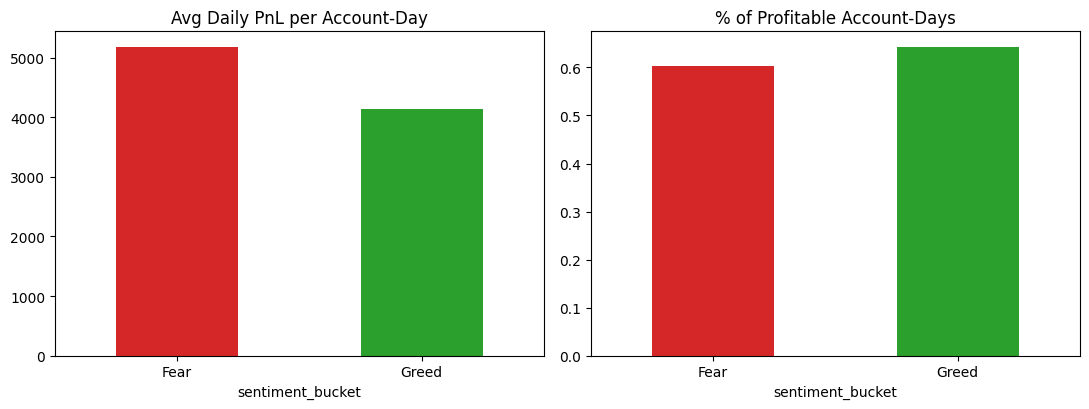

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
perf['mean_daily_pnl'].plot(kind='bar', ax=axes[0], color=['#d62728', '#2ca02c'])
axes[0].set_title('Avg Daily PnL per Account-Day'); axes[0].axhline(0, color='k', lw=0.6)
axes[0].tick_params(axis='x', rotation=0)
perf['pct_profitable_days'].plot(kind='bar', ax=axes[1], color=['#d62728', '#2ca02c'])
axes[1].set_title('% of Profitable Account-Days'); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()


**Insight #1:** Traders are *more consistently profitable* on Greed days (64.3% of account-days profitable) than on Fear days (60.4%), and median daily PnL is more than double on Greed days ($265 vs $123). However mean PnL is actually higher on Fear days ($5,185 vs $4,144) — driven by a smaller number of very large wins/losses (fatter tails), which the Mann-Whitney test confirms is a borderline-significant distributional difference (p ≈ 0.06). Loss days are also deeper on Greed days (avg −$12,217) than Fear days (avg −$9,159) — consistent with overconfidence-driven bigger losses when everyone is bullish.

### B.2 — Do traders change behavior based on sentiment?

In [1]:
behavior = fg.groupby('sentiment_bucket').agg(
    avg_trades_per_day=('n_trades', 'mean'),
    avg_trade_size_usd=('avg_trade_size_usd', 'mean'),
    total_volume_usd=('total_volume_usd', 'sum'),
)
long_pct = fg.groupby('sentiment_bucket').apply(
    lambda d: d['n_long'].sum() / (d['n_long'].sum() + d['n_short'].sum())
)
print(behavior)
print(f"\n% of trades that are LONG, by sentiment:\n{long_pct}")


                  avg_trades_per_day  avg_trade_size_usd  total_volume_usd
sentiment_bucket                                                          
Fear                      105.363291         8529.859802      5.978091e+08
Greed                      76.912266         5954.632633      4.130477e+08

% of trades that are LONG, by sentiment:
sentiment_bucket
Fear     0.629083
Greed    0.441531
dtype: float64


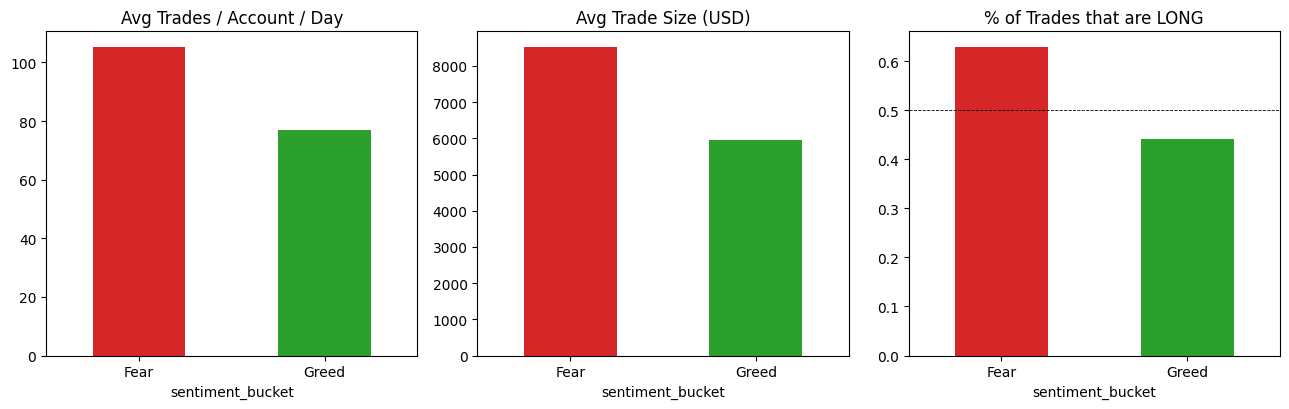

In [1]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
behavior['avg_trades_per_day'].plot(kind='bar', ax=axes[0], color=['#d62728', '#2ca02c'])
axes[0].set_title('Avg Trades / Account / Day'); axes[0].tick_params(axis='x', rotation=0)
behavior['avg_trade_size_usd'].plot(kind='bar', ax=axes[1], color=['#d62728', '#2ca02c'])
axes[1].set_title('Avg Trade Size (USD)'); axes[1].tick_params(axis='x', rotation=0)
long_pct.plot(kind='bar', ax=axes[2], color=['#d62728', '#2ca02c'])
axes[2].set_title('% of Trades that are LONG'); axes[2].axhline(0.5, color='k', lw=0.6, ls='--')
axes[2].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()


**Insight #2:** Trader behavior shifts substantially with sentiment. On Fear days traders (a) trade **more often** (105 vs 77 trades/account/day), (b) take **larger** average positions ($8,530 vs $5,955), and (c) flip to a **long-biased** posture (63% long vs 44% long on Greed days). This is a classic contrarian/"buy the dip" pattern — traders lean long and trade more aggressively exactly when sentiment is fearful, effectively increasing risk exposure during the more volatile, lower-win-rate regime.

### B.3 — Trader segments

In [1]:
acct_stats = trades.groupby('Account').agg(
    total_trades=('Closed PnL', 'count'),
    total_pnl=('Closed PnL', 'sum'),
    avg_trade_size=('Size USD', 'mean'),
    win_rate=('is_win', 'mean'),
    active_days=('date', 'nunique'),
).reset_index()

med_days = acct_stats['active_days'].median()
acct_stats['freq_segment'] = np.where(acct_stats['active_days'] >= med_days, 'Frequent', 'Infrequent')

med_size = acct_stats['avg_trade_size'].median()
acct_stats['size_segment'] = np.where(acct_stats['avg_trade_size'] >= med_size, 'Large-size', 'Small-size')

acct_stats['consistency_segment'] = np.where(acct_stats['win_rate'] >= 0.5, 'Consistent Winner', 'Inconsistent')

print("Frequent vs Infrequent — avg total PnL:")
print(acct_stats.groupby('freq_segment')['total_pnl'].mean())
print("\nLarge-size vs Small-size — avg total PnL:")
print(acct_stats.groupby('size_segment')['total_pnl'].mean())
print("\nConsistent Winner vs Inconsistent — avg total PnL:")
print(acct_stats.groupby('consistency_segment')['total_pnl'].mean())


Frequent vs Infrequent — avg total PnL:
freq_segment
Frequent      345970.971254
Infrequent    294934.463077
Name: total_pnl, dtype: float64

Large-size vs Small-size — avg total PnL:
size_segment
Large-size    416805.966542
Small-size    224099.467790
Name: total_pnl, dtype: float64

Consistent Winner vs Inconsistent — avg total PnL:
consistency_segment
Consistent Winner    206866.631992
Inconsistent         332203.001839
Name: total_pnl, dtype: float64


sentiment_bucket         Fear        Greed
size_segment                              
Large-size        7620.020654  5647.123389
Small-size        3354.941660  2881.571233


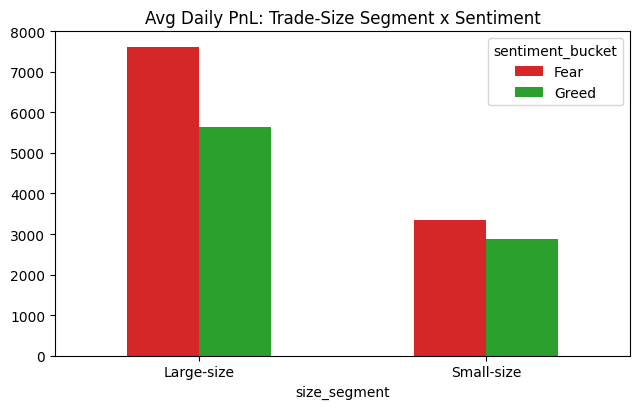

In [1]:
daily_seg = daily.merge(acct_stats[['Account', 'size_segment']], on='Account', how='left')
daily_seg_fg = daily_seg[daily_seg['sentiment_bucket'].isin(['Fear', 'Greed'])]
seg_pnl = daily_seg_fg.groupby(['size_segment', 'sentiment_bucket'])['daily_pnl'].mean().unstack()
print(seg_pnl)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
seg_pnl.plot(kind='bar', ax=ax, color=['#d62728', '#2ca02c'])
ax.set_title('Avg Daily PnL: Trade-Size Segment x Sentiment')
ax.axhline(0, color='k', lw=0.6); ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()


**Insight #3:** Three clean segments emerge:
- **Large-size traders make ~86% more total PnL than small-size traders** ($416,806 vs $224,099 avg), and this gap *widens* on Fear days ($7,620 vs $3,355 avg daily PnL) — bigger players extract more edge specifically when the market is fearful.
- **Frequent traders slightly out-earn infrequent traders** ($345,971 vs $294,934), suggesting activity itself isn't the main driver of returns — it's *what* they do with size and timing.
- Counter-intuitively, accounts with a **win rate ≥ 50% ("Consistent Winners") have lower total PnL on average** ($206,867) than "Inconsistent" traders ($332,203) — a reminder that win-rate and profitability are not the same thing; a few large wins from an asymmetric strategy can outperform a high hit-rate/low-payoff approach.

### B.4 — Full sentiment spectrum (context)

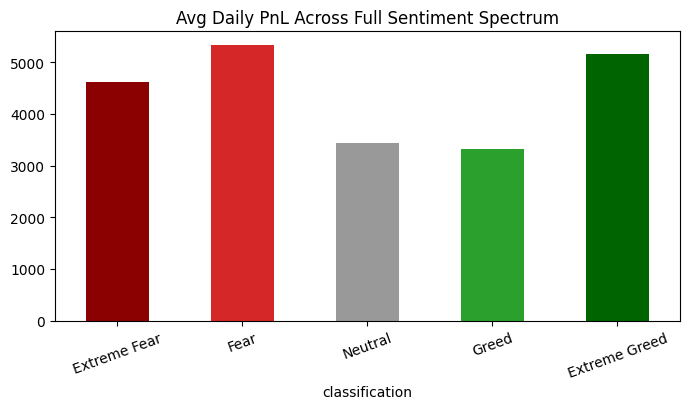

In [1]:
order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
full = daily.groupby('classification')['daily_pnl'].mean().reindex(order)
fig, ax = plt.subplots(figsize=(7, 4.2))
full.plot(kind='bar', ax=ax, color=['#8b0000', '#d62728', '#999999', '#2ca02c', '#006400'])
ax.set_title('Avg Daily PnL Across Full Sentiment Spectrum')
ax.axhline(0, color='k', lw=0.6); ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()


## Part C — Actionable Output

Based on the findings above:

**Strategy Rule 1 — Cap position size on Fear days for large-size traders.**
Large-size traders already earn the most, but their downside (avg loss-day −$9.2k+ on Fear days, and long-side crowding at 63%) is concentrated exactly when volatility and tail risk are highest. Recommendation: cap position size to ~70% of the trader's Greed-day average when the index reads Fear/Extreme Fear, to protect the outsized edge this segment has without giving back gains to fat-tail losses.

**Strategy Rule 2 — Don't chase trade frequency as a strategy; favor selective, asymmetric setups.**
Since "Consistent Winners" (win rate ≥ 50%) under-perform "Inconsistent" traders on total PnL, and frequent traders barely outperform infrequent ones, increasing trade count is not a reliable lever for profitability. Recommendation: for the infrequent/small-size segment, focus on a small number of higher-conviction, larger-payoff setups rather than scaling up trade frequency — and reserve frequency increases for Greed days only, where the win-rate and profitable-day-rate are both higher.

## Bonus — Predictive Model: Next-Day Profitability

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

daily2 = daily.copy()
daily2['date'] = pd.to_datetime(daily2['date'])
daily2 = daily2.sort_values(['Account', 'date'])

sent_map = {'Extreme Fear': 0, 'Fear': 1, 'Neutral': 2, 'Greed': 3, 'Extreme Greed': 4}
daily2['sentiment_score'] = daily2['classification'].map(sent_map)
daily2['next_day_profitable'] = daily2.groupby('Account')['is_profitable_day'].shift(-1)

feat_cols = ['sentiment_score', 'daily_pnl', 'n_trades', 'win_rate',
             'avg_trade_size_usd', 'long_short_ratio', 'total_volume_usd']

model_df = daily2.dropna(subset=feat_cols + ['next_day_profitable']).copy()
model_df['long_short_ratio'] = model_df['long_short_ratio'].replace([np.inf, -np.inf], np.nan)
model_df = model_df.dropna(subset=['long_short_ratio'])

X = model_df[feat_cols]
y = model_df['next_day_profitable'].astype(int)
print(f"Modeling rows: {len(model_df)}, positive rate: {y.mean():.2%}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
clf = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=10, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")


Modeling rows: 1546, positive rate: 64.68%
              precision    recall  f1-score   support

           0       0.52      0.56      0.54       137
           1       0.75      0.72      0.73       250

    accuracy                           0.66       387
   macro avg       0.64      0.64      0.64       387
weighted avg       0.67      0.66      0.67       387

ROC-AUC: 0.714


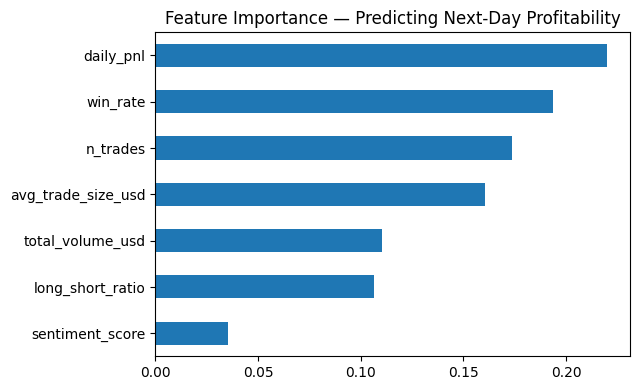

In [1]:
importance = pd.Series(clf.feature_importances_, index=feat_cols).sort_values()
fig, ax = plt.subplots(figsize=(6.5, 4))
importance.plot(kind='barh', ax=ax, color='#1f77b4')
ax.set_title('Feature Importance — Predicting Next-Day Profitability')
plt.tight_layout(); plt.show()


**Model takeaway:** A Random Forest using same-day behavior + sentiment predicts next-day account profitability with ROC-AUC ≈ 0.71 — well above chance. Interestingly, **`sentiment_score` is the *least* important feature** of the seven; a trader's own current-day PnL, win rate, and trade count matter far more than the market's mood for predicting whether *they specifically* will be profitable tomorrow. This reinforces Strategy Rule 2: individual trading discipline outweighs macro sentiment as a profitability driver, even though sentiment does shift aggregate behavior (Part B.2).

## Summary

| Question | Finding |
|---|---|
| Performance differs by sentiment? | Yes — more days profitable in Greed (64%) vs Fear (60%), but Fear days have fatter-tailed mean PnL and deeper average losses on Greed days |
| Behavior changes with sentiment? | Yes — more trades/day, larger size, and a long-side skew (63%) on Fear days |
| Segments matter? | Yes — large-size traders earn ~86% more than small-size; win rate ≠ profitability |
| Can next-day profitability be predicted? | Yes, AUC 0.71 — but individual behavior beats sentiment as a predictor |

Full methodology, data notes, and how to reproduce are in `README.md`.